In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns

from scipy import stats
sns.set_style('ticks')
sns.set_context("notebook", font_scale=1.2, rc={"lines.linewidth": 1.0})
colors =  plt.rcParams['axes.prop_cycle'].by_key()['color']

%matplotlib inline

## SPP and TPP realizations

In [2]:
import matplotlib as mpl
pgf_with_latex = {  # setup matplotlib to use latex for output
    "pgf.texsystem": "pdflatex",  # change this if using xetex or lautex
#     "pgf.texsystem": "xelatex",  # change this if using xetex or lautex
    "text.usetex": True,  # use LaTeX to write all text
    "font.family": "serif",
    "font.serif": [],  # blank entries should cause plots to inherit fonts from the document
    "font.sans-serif": [],
    "font.monospace": [],
    "axes.labelsize": 10,  # LaTeX default is 10pt font.
    "font.size": 10,
    "legend.fontsize": 8,  # Make the legend/label fonts a little smaller
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
#     "figure.figsize": figsize(0.9),  # default fig size of 0.9 textwidth
    "pgf.preamble": [
        r"\usepackage[utf8x]{inputenc}",  # use utf8 fonts because your computer can handle it :)
        r"\usepackage[T1]{fontenc}",  # plots will be generated using this preamble
        r"\usepackage{amsmath}",
        r"\usepackage{accents}",  # for hattilde
        r"\usepackage{xcolor}",  # for hattilde
        r"\newlength{\dtildeheight}"
        r"\newcommand{\hattilde}[1]{"
        r"\settoheight{\dtildeheight}{\ensuremath{\tilde{#1}}}"
        r"\addtolength{\dtildeheight}{-0.1ex}"
        r"\hat{\vphantom{\rule{1pt}{\dtildeheight}}"
        r"\smash{\tilde{#1}}}}",
        r"\newcommand*{\mat}[1]{\boldsymbol{#1}}",
    ]
}
mpl.rcParams.update(pgf_with_latex)

/home/shchur/miniconda/envs/torch/lib/python3.8/_collections_abc.py:832: MatplotlibDeprecationWarning: Support for setting the 'text.latex.preamble' or 'pgf.preamble' rcParam to a list of strings is deprecated since 3.3 and will be removed two minor releases later; set it to a single string instead.
  self[key] = other[key]


In [3]:
from sklearn.datasets import make_blobs

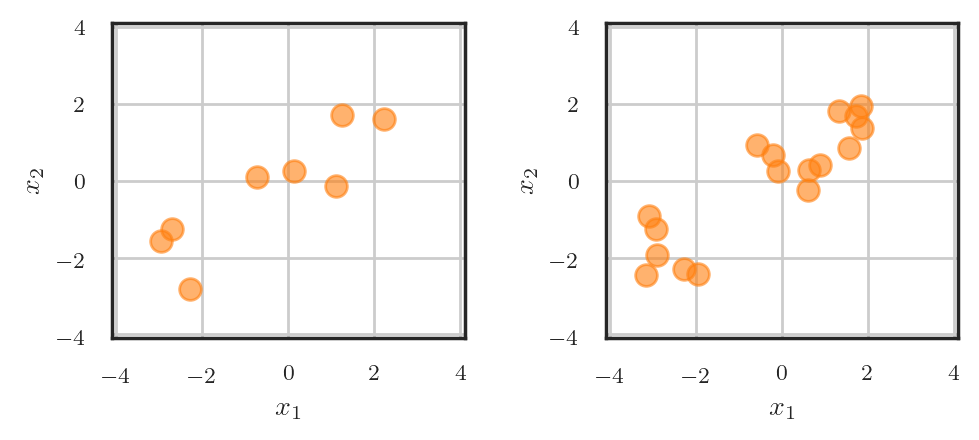

In [4]:
sns.set_style('white')
fig, axes = plt.subplots(ncols=2, dpi=200, figsize=(5, 2.3), sharey=False, sharex=True)
np.random.seed(158)
centers = np.random.uniform(-3, 3, size=[3, 2])
for i, ax in enumerate(axes):
    X, y = make_blobs(8 + i * 9, centers=centers, center_box=(-3, 3), cluster_std=0.5, random_state=123 + i)
    ax.scatter(X[:, 0], X[:, 1], s=61, alpha=0.6, c=colors[1])
    ax.set(ylim=(-4.1, 4.1), xlim=(-4.1, 4.1),)
    ax.set_xlabel(r"$x_1$", fontsize=10)
#     if i == 0:
    ax.grid()
    ax.set_ylabel(r"$x_2$", fontsize=10)
    ax.tick_params(labelsize=8)
fig.tight_layout()
plt.subplots_adjust(wspace=0.4)
# plt.margins(0,0)
fig.savefig("../img/posts/tpp1/spp_sample.png", bbox_inches="tight")

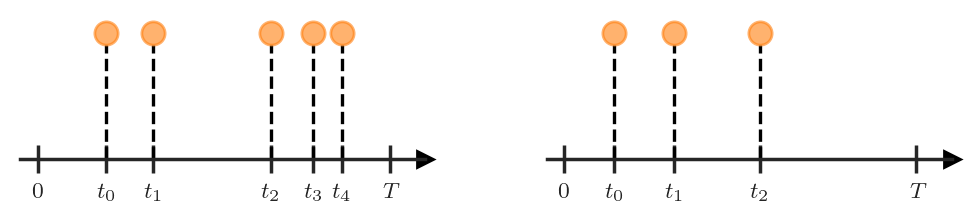

In [5]:
sns.set_style('ticks')
np.random.seed(125)
seeds = [135, 130]
cnts = [5, 3]
fig, axes = plt.subplots(ncols=2, dpi=200, figsize=(5, 1.2))

height = 0.2

rc = {"xtick.direction" : "inout", "ytick.direction" : "inout",
      "xtick.major.size" : 5, "ytick.major.size" : 5,}
for idx, ax in enumerate(axes):
    with plt.rc_context(rc):
        np.random.seed(seeds[idx])
        x = np.sort(np.random.uniform(0, 1, size=cnts[idx]))
        for xx in x:
            ax.vlines(xx, ymin=0, ymax=height - 0.02, colors='k', zorder=1, linewidth=1.2, linestyle='--')
        ax.scatter(x, height * np.ones_like(x), s=70, zorder=2, c=colors[1], alpha=0.6)
    #     ax.plot(x, y)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_position('zero')
        ax.spines['top'].set_visible(False)
        ax.yaxis.set_tick_params(labelleft=False, left=False)
        ax.xaxis.set_tick_params(length=10)
        ax.plot((1), (0), ls="", marker=">", ms=6, color="k",
            transform=ax.get_yaxis_transform(), clip_on=False)
        ax.set(xlim=(-0.05, 1.1))
        ax.set_xticks([0] + list(x) + [1])
        ax.set_xticklabels([r'$0$'] + [f'$t_{i}$' for i in range(len(x))] + [r'$T$'])
        ax.tick_params(labelsize=8)
    ax.set(ylim=(-0.05, height + 0.02))
fig.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.margins(0,0)
fig.savefig("../img/posts/tpp1/tpp_sample.png")

## PDF / CDF / SF / hazard

In [6]:
x = np.linspace(0, 2.5, 1000)
dist = stats.weibull_min(2.5, scale=1.0)
t = 0.7
dt = 0.11

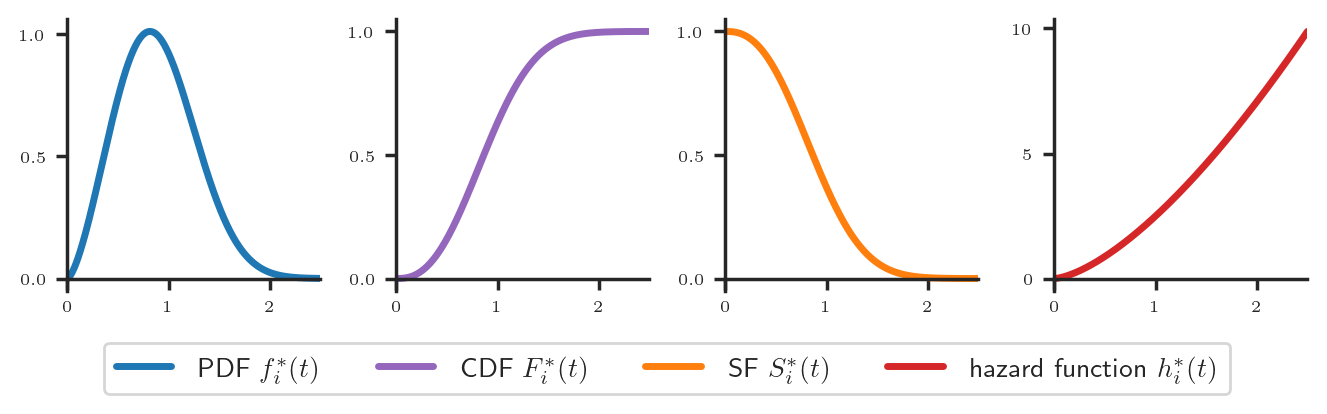

In [201]:
sns.set_style('ticks')
fig, axes = plt.subplots(ncols=4, dpi=200, figsize=(8, 1.8))
axes[0].plot(x, dist.pdf(x), c=colors[0], linewidth=2.5, label=r"PDF $f_i^*(t)$")
axes[1].plot(x, dist.cdf(x), c=colors[4], linewidth=2.5, label=r"CDF $F_i^*(t)$")
axes[2].plot(x, dist.sf(x), c=colors[1], linewidth=2.5, label=r"SF $S_i^*(t)$")
axes[3].plot(x, dist.pdf(x) / dist.sf(x), c=colors[3], linewidth=2.5, label=r"hazard function $h_i^*(t)$")

for idx, ax in enumerate(axes):
#     ax.spines['left'].set_visible(False)
#     ax.legend(fontsize=10)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position('zero')
    ax.spines['top'].set_visible(False)
#     ax.yaxis.set_tick_params(labelleft=False, left=False)
    if idx != 3:
        ax.set_yticks([0.0, 0.5, 1.0])
    else:
        ax.set_yticks([0.0, 5.0, 10.0])
    ax.yaxis.set_tick_params(length=4, labelsize=6)
    ax.xaxis.set_tick_params(length=4, labelsize=6)
    ax.set_xticks([0.0, 1.0, 2.0])
#     ax.plot((1), (0), ls="", marker=">", ms=3, color="k",
#         transform=ax.get_yaxis_transform(), clip_on=False)
#     ax.plot((0), (1), ls="", marker="^", ms=3, color="k",
#         transform=ax.get_xaxis_transform(), clip_on=False)
    ax.set_xlim(0, 2.5)
    
    
handles = [ax.get_legend_handles_labels()[0][0] for ax in axes]
labels = [ax.get_legend_handles_labels()[1][0] for ax in axes]
fig.legend(handles, labels, loc='lower center', ncol=4, handletextpad=1, bbox_to_anchor=(0.5, -0.2), fontsize=10)
plt.subplots_adjust(wspace=0.3)

fig.savefig("../img/posts/tpp1/pdf_cdf_sf_hazard.png", bbox_inches="tight")

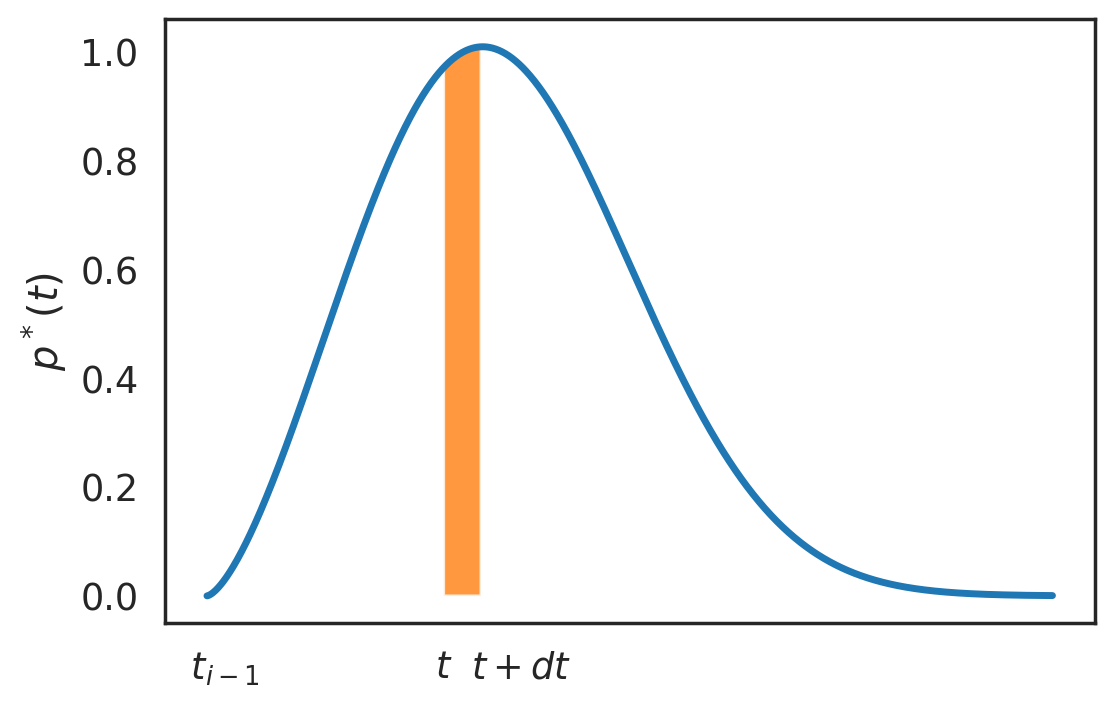

In [20]:
fig = plt.figure(dpi=200)
ax = plt.gca()

p = dist.pdf(x)
# rect = patches.Rectangle((t, 0), dt, dist.pdf(t), linewidth=0, 
#                          facecolor=colors[1], alpha=0.7)
rect = patches.Polygon([[t, 0], 
                        [t + dt, 0], 
                        [t + dt, dist.pdf(t + dt)], 
                        [t + 0.5 * dt, dist.pdf(t + 0.5 * dt)], 
                        [t, dist.pdf(t)]],
                 facecolor=colors[1], alpha=0.8)
ax.add_patch(rect)
plt.plot(x, p, color=colors[0], linewidth=2.5)
locs, labels = plt.xticks(np.array([0, t, t + dt]), (r"$\quad t_{i-1}$", r"$t$", r"$\;\qquad t + dt$"))
ax.xaxis.grid(False)

plt.ylabel(r'$p^*(t)$')
plt.show()
# plt.xlabel(r'$t$')

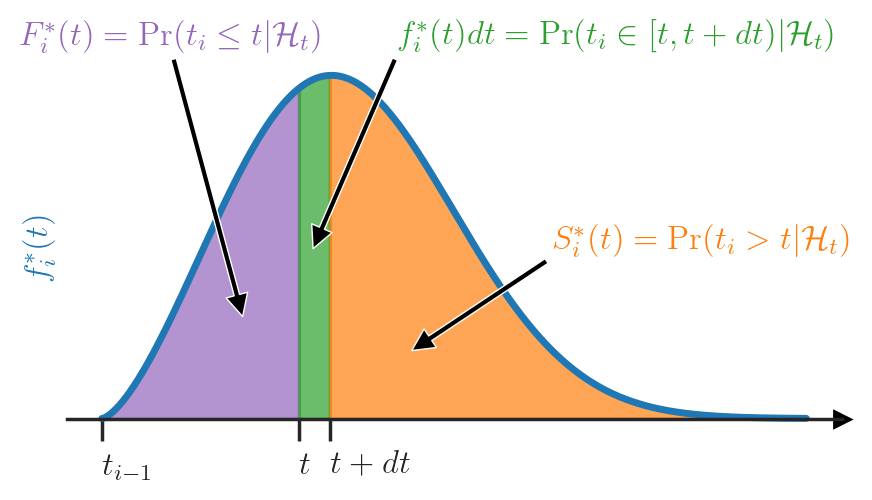

In [200]:
sns.set_style('ticks')
fig = plt.figure(dpi=200, figsize=(5, 2.5))
ax = plt.gca()

p = dist.pdf(x)
plt.plot(x, p, color=colors[0], linewidth=2.5)
x_before = x[x < t]
x_dt = x[(x >= t) & (x < t + dt)]
x_after = x[x >= t + dt]

ax.fill_between(x_before, dist.pdf(x_before), 0, alpha=0.7, color=colors[4])
ax.fill_between(x_dt, dist.pdf(x_dt), 0, alpha=0.7, color=colors[2])
ax.fill_between(x_after, dist.pdf(x_after), 0, alpha=0.7, color=colors[1])
locs, labels = plt.xticks(np.array([0, t, t + dt]), (r"$\quad t_{i-1}$", r"$t$", r"$\;\;\; t + dt$"))
# ax.xaxis.grid(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.yaxis.set_tick_params(labelleft=False, left=False)
ax.xaxis.set_tick_params(length=8, labelsize=12)
ax.plot((1), (0), ls="", marker=">", ms=6, color="k",
    transform=ax.get_yaxis_transform(), clip_on=False)
for tick in ax.xaxis.get_majorticklabels():
    tick.set_horizontalalignment("left")

ax.annotate(r"$S_i^*(t) = \Pr(t_i > t | \mathcal{H}_{t})$", (1.1, 0.2), c=colors[1], fontsize=12, xytext=(1.6, 0.5),
            arrowprops=dict(facecolor="k", width=2, linewidth=0.5, headwidth=8, headlength=8))
# ax.text(1.6, 0.5, r"$S_i^*(t) = \Pr(t_i > t | \mathcal{H}_{t})$", c=colors[1], fontsize=12)
# ax.arrow(1.6, 0.5, -0.5, -0.2, color='k', )

# ax.text(1.05, 1.1, r"$f_i^*(t)dt = \Pr(t_i \in [t, t+dt) | \mathcal{H}_{t})$", c=colors[2], fontsize=12)
ax.annotate(r"$f_i^*(t)dt = \Pr(t_i \in [t, t+dt) | \mathcal{H}_{t})$", (0.75, 0.5), c=colors[2], fontsize=12, xytext=(1.05, 1.1),
            arrowprops=dict(facecolor="k", width=2, linewidth=0.5, headwidth=8, headlength=8))

# ax.text(-0.29, 1.1, r"$F_i^*(t) = \Pr(t_i < t | \mathcal{H}_{t})$", c=colors[4], fontsize=12)
ax.annotate(r"$F_i^*(t) = \Pr(t_i \le t | \mathcal{H}_{t})$", (0.5, 0.3), c=colors[4], fontsize=12, xytext=(-0.29, 1.1),
            arrowprops=dict(facecolor="k", width=2, linewidth=0.5, headwidth=8, headlength=8))

ax.set_ylabel(r'$f^*_i(t)$', fontsize=12, c=colors[0])
plt.show()
fig.savefig("../img/posts/tpp1/pdf_cdf_sf.png")